![image](https://github.com/eWaterCycle/ewatercycle/raw/main/docs/examples/logo.png)

# Running PCR-GLOBWB2 for a Custom Region with eWaterCycle

## What this tutorial does

This tutorial shows how to run PCR-GLOBWB for a custom region selected by the user. Instead of preparing inputs for a predefined model area, we define the region ourselves, create a matching clonemap, and request forcing data for that same area.

The notebook follows this workflow:

1. Define the boundary and coordinates of the custom region.
2. Create a clonemap that covers the selected region.
3. Generate or load forcing data for the custom region.
4. Configure and run PCR-GLOBWB with these region-specific inputs.
5. Inspect the output and compare a selected station time series with observations.

To adapt the tutorial, change the catchment extent, shapefile, station coordinates, and related file paths in the region-selection cells. The code cells are ready to run in order.

More information about data, configuration and installation instructions can be found in the [System setup](https://ewatercycle.readthedocs.io/en/latest/system_setup.html) in the eWaterCycle documentation.





## 1. Import packages and set the project location

The next cells import the Python packages used for file handling, plotting, forcing generation, and model setup. The project root is taken from the current working directory so that the example can refer to files with paths relative to the notebook.

In [1]:
import logging
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

logger = logging.getLogger("esmvalcore")
logger.setLevel(logging.WARNING)

In [2]:
import xarray as xr
#from rich import print
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from cartopy import crs
from cartopy import feature as cfeature
import shutil
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader

import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.parameter_sets
from ewatercycle.container import ContainerImage



In [3]:
project_root = Path.cwd()

## 2. Define the custom region

The custom region to be modelled is described with a bounding box and a shapefile. The bounding box controls the area covered by the input grid and forcing data (clonemap). The shapefile is used to display the selected catchment, while the station coordinates mark the location used later to extract a modelled time series.

For another region, replace these coordinates, the shapefile path, and the station coordinates with the values for that region.

Keeping the coordinates in `clonemap_extents` lets the clonemap and forcing-generation steps use the same region definition.

NOTE the bounding box latitude and longitude values should be integers.

In [4]:
# Catchment/area bounding boxes. The bounding box latitude and longitude values should be integers.
clonemap_extents = {
    "kemijoki": {
        "latitude": (64, 70),
        "longitude": (20, 32)
    },
}

shp = shpreader.Reader("./data_example/kemijoki/shapefiles/kemijoki.shp")

grdc_latitude = 65.792
grdc_longitude = 24.54



esmvaltool_padding = 0  # degrees lat/lon



## 3. Plotting overview of the custom region


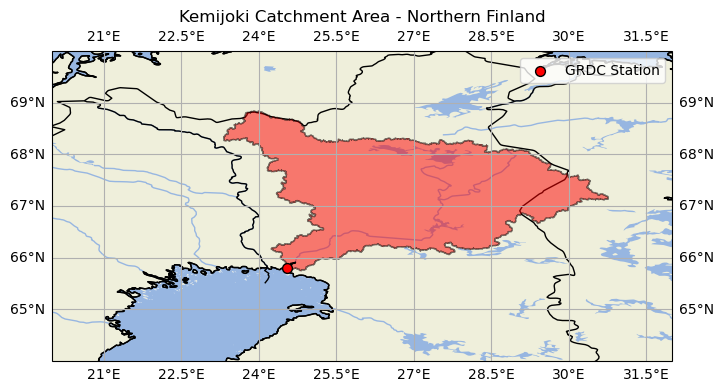

In [5]:


fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)


ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAKES)
ax.add_feature(cfeature.RIVERS)

ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)

ax.add_geometries(
    shp.geometries(),
    crs=ccrs.PlateCarree(),
    facecolor="red",
    edgecolor="black",
    alpha=0.5
)

extent = clonemap_extents["kemijoki"]

ax.set_extent(
    [
        *extent["longitude"],
        *extent["latitude"],
    ],
    crs=ccrs.PlateCarree()
)


ax.coastlines()
ax.scatter(grdc_longitude, grdc_latitude, s=50,
           c="red", edgecolors="black", zorder=10,
           label="GRDC Station")
ax.legend()
ax.gridlines(draw_labels=True)
plt.title("Kemijoki Catchment Area - Northern Finland")
plt.show()

## 4. Create a clonemap for the custom region

PCR-GLOBWB uses a clonemap to define the model grid. Here we extract a smaller regional clonemap from the global map using the custom-region bounding box. The function checks that the selected extent can be divided into whole cells at the chosen forcing resolution.

The resulting regional map is used later as both the model clonemap and landmask.

In [6]:
import subprocess
def create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment):
    """Create new clonemap compatible with forcing data resolution."""
    dlon = lonmax - lonmin
    dlat = latmax - latmin

    msg = (
        "The clonemap extent divided by the forcing resolution must yield"
        "an integer number of grid cells."
    )
    assert dlon % forcing_resolution == 0, f"Longitudes not compatible. {msg}"
    assert dlat % forcing_resolution == 0, f"Latitudes not compatible. {msg}"

    clonemap_dir = (
        "/data/shared/parameter-sets/pcrglobwb_global/global_05min/cloneMaps"
    )
    globalclonemap = clonemap_dir + "/clone_global_05min.map"
    outputclonemap = f"./data_example/{catchment.lower()}_05min.map"  # copy to clonemap dir after ensuring it is correct

    subprocess.call(
        f"gdal_translate -of PCRaster {globalclonemap} -projwin "
        f"{lonmin} {latmax} {lonmax} {latmin} {outputclonemap}",
        shell=True,
    )
    return outputclonemap



In [7]:


forcing_resolution = 0.75  # this has to be 0.75
for (catchment, extents) in clonemap_extents.items():
    latmin, latmax = extents["latitude"]
    lonmin, lonmax = extents["longitude"]
    print(
        create_clonemap(lonmin, latmin, lonmax, latmax, forcing_resolution, catchment)
    )



Input file size is 4320, 2160
0...10...20...30...40...50...60...70...80...90...100 - done.
./data_example/kemijoki_05min.map


The following cell creates the regional clonemap for each entry in `clonemap_extents`. In this example there is one catchment, but the loop also supports adding more regions later.

## 5. Generate or load the forcing data

Forcing data is prepared for the selected dates and region. The cell first looks for an existing forcing YAML file. If none is found, it generates the forcing data; otherwise, it loads the existing forcing setup. This makes the notebook easier to rerun without recreating files that are already available.

The forcing area is selected from the same custom-region extent. It should cover the complete model grid, and it can be enlarged with `esmvaltool_padding` when additional space around the region is needed.

In [8]:

catchment, extents = next(iter(clonemap_extents.items()))

lon_min_f, lon_max_f = extents["longitude"]
lat_min_f, lat_max_f = extents["latitude"]

start_time_ERA5="1995-01-01T00:00:00Z"
end_time_ERA5="2000-12-31T00:00:00Z"

# Forcing data will be stored here
forcing_root =  project_root/f"data_example/{catchment}/forcing"
yaml_files = list(forcing_root.rglob("ewatercycle_forcing.yaml"))

if not yaml_files:
    print("Forcing not found — generating.")
    example_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].generate(
        dataset="ERA5",
        start_time=start_time_ERA5,
        end_time=end_time_ERA5,
        shape=f"./data_example/kemijoki/shapefiles/kemijoki.shp",
        extract_region={
            "start_longitude": lon_min_f - esmvaltool_padding,
            "end_longitude": lon_max_f + esmvaltool_padding,
            "start_latitude": lat_min_f - esmvaltool_padding,
            "end_latitude": lat_max_f + esmvaltool_padding,
        },
        start_time_climatology=start_time_ERA5,
        end_time_climatology=end_time_ERA5,
        directory=forcing_root,
    )

else:
    forcing_yaml = yaml_files[0]
    print(f"Forcing already exists — loading from {forcing_yaml.parent}")

    example_forcing = ewatercycle.forcing.sources["PCRGlobWBForcing"].load(
        directory=forcing_yaml.parent,
    )



Forcing already exists — loading from /home/mmelotto/ewatercycle-pcrglobwb/docs/data_example/kemijoki/forcing/work/diagnostic/script


## 6. Inspect the forcing files

The forcing object points to separate NetCDF files for the input variables. This cell opens each file, prints its structure, and plots one time slice so we can check that the files contain data over the selected region before starting the model.

<xarray.Dataset> Size: 13MB
Dimensions:    (time: 2557, lat: 25, lon: 49, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 20kB 1994-01-01 1994-01-02 ... 2000-12-31
  * lat        (lat) float32 100B 70.0 69.75 69.5 69.25 ... 64.5 64.25 64.0
  * lon        (lon) float32 196B 20.0 20.25 20.5 20.75 ... 31.5 31.75 32.0
    height     float64 8B 2.0
Dimensions without coordinates: bnds
Data variables:
    tas        (time, lat, lon) float32 13MB 269.8 270.2 270.3 ... 269.9 270.0
    time_bnds  (time, bnds) datetime64[ns] 41kB 1993-12-31T12:00:00 ... 2000-...
    lat_bnds   (lat, bnds) float32 200B 70.12 69.88 69.88 ... 64.12 64.12 63.88
    lon_bnds   (lon, bnds) float32 392B 19.88 20.12 20.12 ... 31.88 31.88 32.12
Attributes:
    Conventions:  CF-1.7
    software:     Created with ESMValTool v2.15.0
    caption:      Forcings for the PCR-GLOBWB hydrological model.
------------------------
<xarray.Dataset> Size: 13MB
Dimensions:    (time: 2557, lat: 25, lon: 49, bnds: 2)
Coordinat

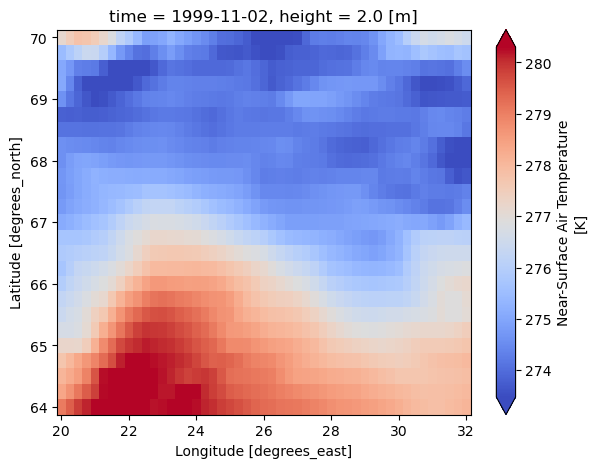

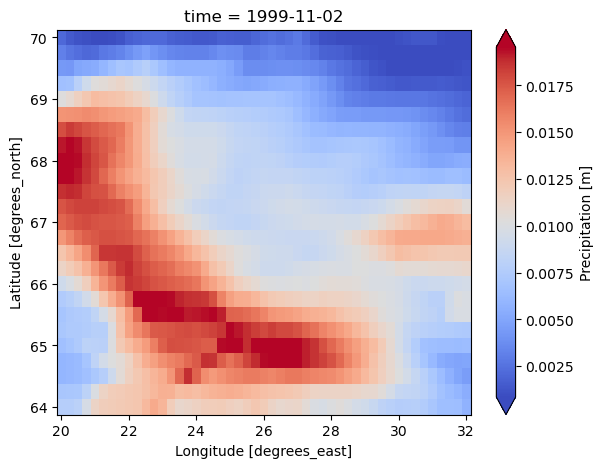

In [9]:
for file_name in [example_forcing.temperatureNC, example_forcing.precipitationNC]:
    dataset = xr.load_dataset(f"{example_forcing.directory}/{file_name}")
    print(dataset)
    print("------------------------")
    var = list(dataset.data_vars.keys())[0]
    dataset[var].isel(time=-426).plot(cmap="coolwarm", robust=True, size=5)

## 7. Configure the model

The model needs a parameter set, the forcing object, a clonemap, a landmask, and a container image. These objects describe where the model inputs are located and which executable environment should run PCR-GLOBWB. The next cell combines them into one model instance.

In [10]:

pcr_glob_directory = Path("/data/shared/parameter-sets/pcrglobwb_global")
INI_FILES = Path("./data_example")
parameter_set_example = ewatercycle.parameter_sets.ParameterSet(
    name="custom_parameter_set",
    directory=pcr_glob_directory,
    config=INI_FILES / "uncalibrated.ini",
    target_model="pcrglobwb",
    supported_model_versions={"v0.2.3"},
)


cloneMap_path = Path.cwd() /"data_example"/ f"{catchment.lower()}_05min.map"




In [11]:
pcrglob_example = ewatercycle.models.PCRGlobWB(
    parameter_set=parameter_set_example,
    forcing=example_forcing,
    cloneMap=cloneMap_path,
    landmask=cloneMap_path,
)

#print(pcrglob_example)

## 8. Choose the simulation period

The forcing period and the model simulation period do not have to be identical. Here we choose the dates for this example and calculate the number of updates needed by the run loop.

In [12]:
# Define the start and end dates for the experiment. These can be defined independently from the start and and end dates for the forcing data.

experiment_start_date = "1999-11-01T00:00:00Z"
experiment_end_date = "2000-12-30T00:00:00Z"



# Convert ISO 8601 strings to datetime objects for progress tracking.
start_time = datetime.strptime(experiment_start_date, "%Y-%m-%dT%H:%M:%SZ")
end_time = datetime.strptime(experiment_end_date, "%Y-%m-%dT%H:%M:%SZ")

delta = end_time - start_time
number_of_days = delta.days
print(f"Number of days to model: {number_of_days}")




Number of days to model: 425


## 9. Prepare and initialize the experiment

Before running the model, we remove the previous example directory so that the output belongs to the current setup. The `setup` call creates the configuration and experiment directory, and `initialize` starts the model with that configuration.

In [13]:

# Remove previous experiment directories before setup to keep the notebook reproducible.
for cfg_dir in [
    Path("kemijoki_experiment"),

]:
    if cfg_dir.exists():
        shutil.rmtree(cfg_dir)

In [14]:
pcrglob_example_config, pcrglob_example_dir = pcrglob_example.setup(
    start_time=experiment_start_date,
    end_time=experiment_end_date,
    max_spinups_in_years=0,
    cfg_dir="kemijoki_experiment",
)
pcrglob_example_config, pcrglob_example_dir

('/home/mmelotto/ewatercycle-pcrglobwb/docs/kemijoki_experiment/pcrglobwb_ewatercycle.ini',
 '/home/mmelotto/ewatercycle-pcrglobwb/docs/kemijoki_experiment')

In [15]:
# Initialize the model with the configuration generated by the setup method. This can take some minutes.
pcrglob_example.initialize(pcrglob_example_config)

## 10. Run the model and store a station time series

The model is advanced one timestep at a time. Before the loop, `timeseries` is created as a pandas DataFrame with the model dates as its time index and one column named `experiment`.

During each update, the notebook reads discharge at the selected station and stores that value in the row for the current model time. The resulting DataFrame contains one discharge value per timestep and is used by the following plot to show the modelled station time series.

In [16]:
time = pd.date_range(pcrglob_example.start_time_as_isostr, pcrglob_example.end_time_as_isostr)
timeseries = pd.DataFrame(
    index=pd.Index(time, name="time"), columns=["experiment"]
)
timeseries.head()

,experiment
time,
1999-11-01 00:00:00+00:00,NaN
1999-11-02 00:00:00+00:00,NaN
1999-11-03 00:00:00+00:00,NaN
1999-11-04 00:00:00+00:00,NaN
1999-11-05 00:00:00+00:00,NaN


In [17]:
# running the model

for i in tqdm(range(number_of_days), desc="Running pcrglobwb2 experiment"):
    pcrglob_example.update()

    discharge_at_station = pcrglob_example.get_value_at_coords(
        "discharge", lat=[grdc_latitude], lon=[grdc_longitude]
    )
    time = pcrglob_example.time_as_isostr
    timeseries.loc[time, "experiment"] = discharge_at_station[0]

print("experiments finished.")

Running pcrglobwb2 experiment: 100%|██████████| 425/425 [16:09<00:00,  2.28s/it]

experiments finished.


<Axes: title={'center': 'Modelled discharge using PCRGLOBWB2'}, xlabel='time', ylabel='Discharge [m3/s]'>

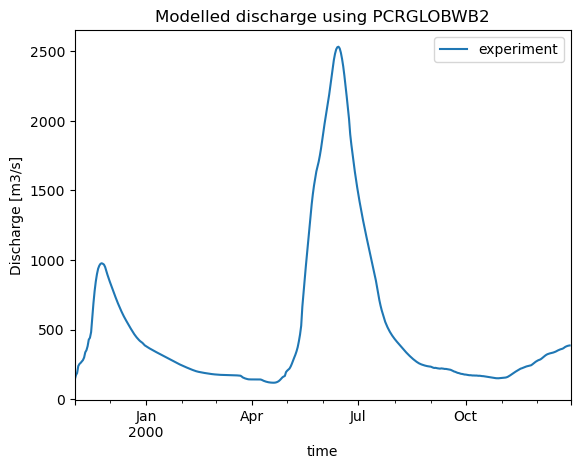

In [18]:
# plot using timeseries 
timeseries.plot(title="Modelled discharge using PCRGLOBWB2", ylabel="Discharge [m3/s]")

## 11. Inspect the model output



PCR-GLOBWB can write model results to NetCDF files in the specified experiment directory. In this case the daily discharge data is saved. Which files are stored can be defined in the .ini file

 We first plot the spatial discharge field from the final timestep, then select the grid cell nearest to the station and plot its complete time series.

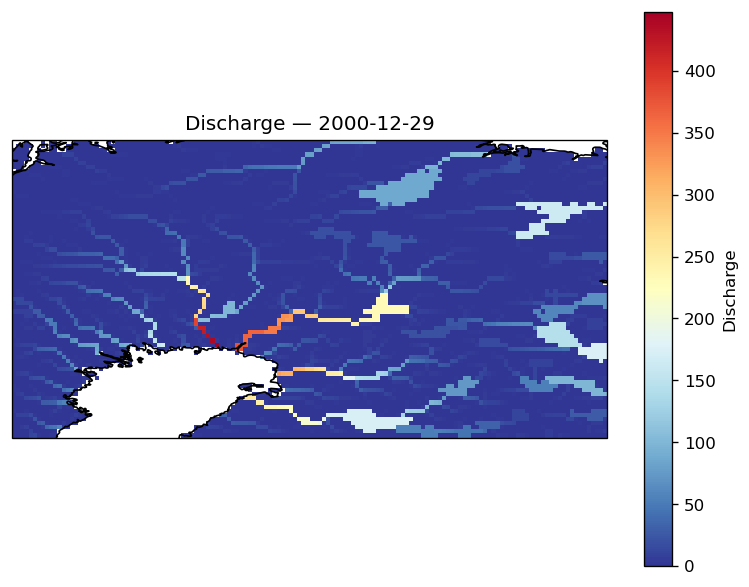

In [19]:
nc_path = "./kemijoki_experiment/netcdf/discharge_dailyTot_output.nc"

ds = xr.open_dataset(nc_path)

fig = plt.figure(figsize=(8, 6), dpi=120)
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())

ds["discharge"].isel(time=-1).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdYlBu_r",
    cbar_kwargs={"label": "Discharge"},
)

ax.coastlines()
ax.set_title(f"Discharge — {ds.time.isel(time=-1).dt.strftime('%Y-%m-%d').item()}")

plt.show()

The point selection uses the nearest available model grid cell to the station coordinates. This is useful when the station does not fall exactly on a model grid cell.

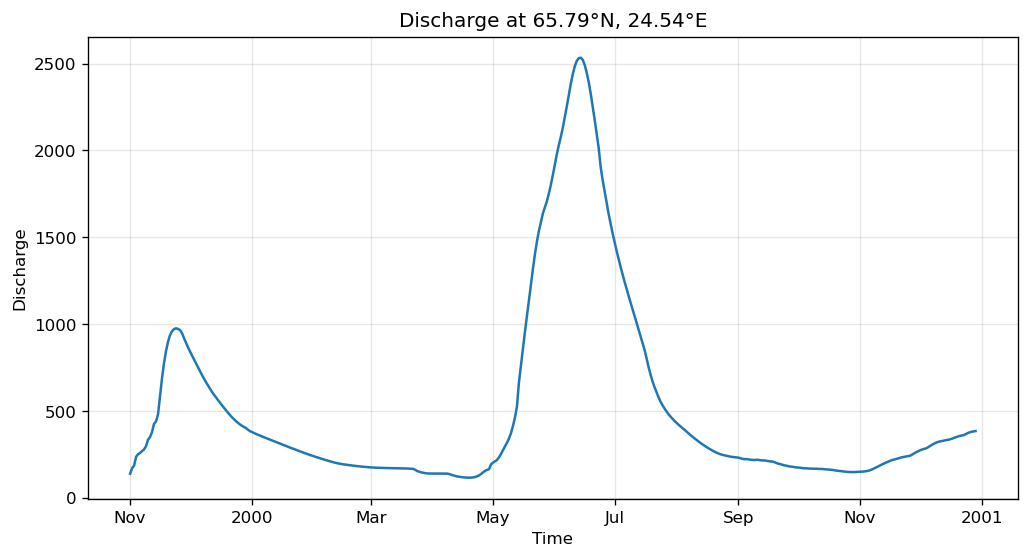

In [20]:
# Select nearest grid cell to the requested location
point = ds["discharge"].sel(
    lat=grdc_latitude,
    lon=grdc_longitude,
    method="nearest",
)


# Plot time series
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

point.plot(ax=ax)

ax.set_xlabel("Time")
ax.set_ylabel("Discharge")
ax.set_title(
    f"Discharge at {point.lat.values:.2f}°N, "
    f"{point.lon.values:.2f}°E"
)

ax.grid(True, alpha=0.3)

plt.show()

## 12. Load observations for comparison

The final part of the tutorial loads a GRDC station time series for the same location and a chosen date range. The observation data is used only to create a side-by-side time-series plot with the model output.

In [21]:
# eWaterCycle observation module
from ewatercycle.observation.grdc import get_grdc_data
station_id = "6854700"

grdc_start_date = "1996-01-01T00:00:00Z"
grdc_end_date   = "2000-12-31T00:00:00Z"

In [22]:
observations_ds = get_grdc_data(
    station_id=station_id,
    start_time=grdc_start_date,
    end_time=grdc_end_date, 
)

Text(0, 0.5, 'Discharge (m³/s)')

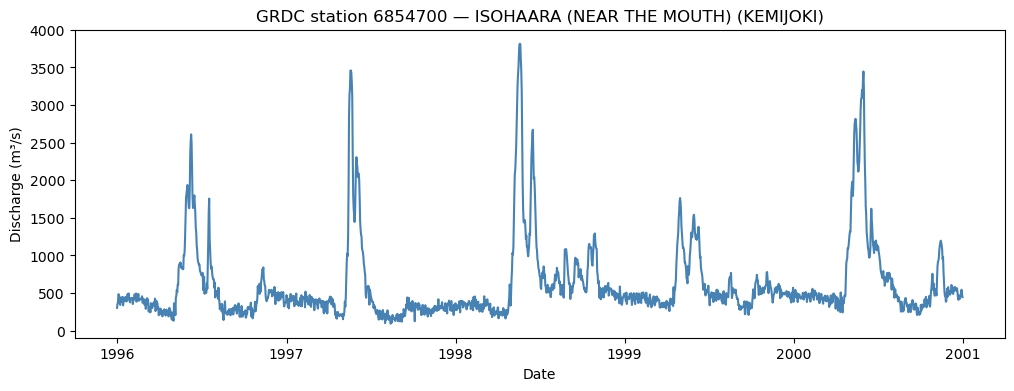

In [23]:
station_name = str(observations_ds["station_name"].values)
river_name   = str(observations_ds["river_name"].values)

# Mask the -999 missing value sentinel before plotting
streamflow = observations_ds["streamflow"].where(observations_ds["streamflow"] != -999)

plt.figure(figsize=(12, 4))
streamflow.plot(color="steelblue")
plt.title(f"GRDC station {station_id} — {station_name} ({river_name})")
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
# plt.tight_layout()

## 13. Compare the two time series

The last plot filters both datasets to the same year and displays them on one set of axes. This makes it easy to inspect whether the model and observation series cover the same dates and to compare their values at the selected station.

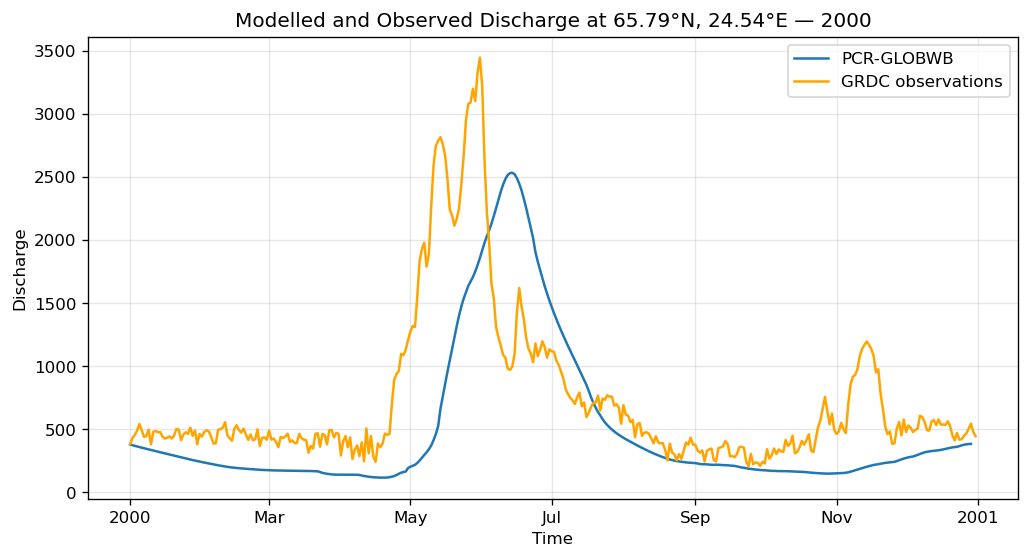

In [24]:
# Select only 2000
point_2000 = point.sel(time=slice("2000-01-01", "2000-12-31"))
streamflow_2000 = streamflow.sel(time=slice("2000-01-01", "2000-12-31"))



# Plot time series
fig, ax = plt.subplots(figsize=(10, 5), dpi=120)

point_2000.plot(ax=ax, label="PCR-GLOBWB")
streamflow_2000.plot(ax=ax, color="orange", label="GRDC observations")

ax.set_xlabel("Time")
ax.set_ylabel("Discharge")
ax.set_title(
    f"Modelled and Observed Discharge at {point.lat.values:.2f}°N, "
    f"{point.lon.values:.2f}°E — 2000"
)

ax.grid(True, alpha=0.3)
ax.legend()

plt.show()